<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/form-4/insider-trading-api-example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<a href="https://github.com/SEC-API-io/sec-api-cookbook/blob/main/notebooks/form-4/insider-trading-api-example.ipynb" target="_blank"><img src="https://img.shields.io/badge/View%20on-GitHub-181717?logo=github" alt="View on GitHub"/></a>


# Insider Trading Disclosures: Analyzing SEC Forms 3, 4, and 5

Corporate insiders — directors, executive officers, and beneficial owners of more than 10% of a registered class of equity securities — are required to file Forms 3, 4, and 5 with the SEC under Section 16(a) of the Securities Exchange Act of 1934. These filings, taken together, form the most detailed public record of who inside an issuer is buying, selling, exercising options, receiving compensation grants, gifting shares, or unwinding derivative positions — and when. Form 4 alone is the heartbeat of insider-trading analytics: it must be filed within two business days of any change in beneficial ownership, making it the fastest-settling structured dataset the SEC publishes.

This notebook turns those Section 16 disclosures into a queryable, plottable dataset using the [sec-api Python SDK](https://sec-api.io/docs/insider-ownership-trading-api). By the end you will be able to:

1. **Build targeted Lucene queries** against the Insider Trading API — by ticker, CIK, insider role, transaction code, or footnote text.
2. **Flatten derivative and non-derivative transactions** from raw filings into tidy pandas DataFrames, keeping every field the SEC exposes (including both the non-derivative and derivative tables).
3. **Produce publication-quality visualizations** of insider activity: time-series bar charts, transaction-code heatmaps, and role-stacked monthly activity plots.

## Regulatory background

**Section 16(a) of the Securities Exchange Act of 1934** imposes reporting obligations on every person who is directly or indirectly the beneficial owner of more than 10% of any class of equity security registered under Section 12, and on every director or officer of the issuer of such security. These insiders must file initial and updated statements of beneficial ownership with the Commission. See the SEC staff's [Compliance and Disclosure Interpretations on Section 16 and Related Rules and Forms](https://www.sec.gov/rules-regulations/staff-guidance/compliance-disclosure-interpretations/exchange-act-section-16-related-rules-forms).

**Rule 16a-3** (17 CFR § 240.16a-3) implements Section 16(a) by specifying which form is filed at which time: **Form 3** is the initial statement of beneficial ownership, due within 10 days of becoming an insider; **Form 4** reports subsequent changes in ownership; and **Form 5** is an annual catch-up for transactions that were exempt from Form 4 reporting. At the election of the reporting person, any transaction otherwise reportable on Form 5 may be reported earlier on Form 4. The rule text is available at [Cornell LII](https://www.law.cornell.edu/cfr/text/17/240.16a-3) and the [eCFR](https://www.ecfr.gov/current/title-17/chapter-II/part-240/subpart-A/subject-group-ECFRb6f97296437637e/section-240.16a-3). Form 4 itself is prescribed by [17 CFR § 249.104](https://www.law.cornell.edu/cfr/text/17/249.104).

**Section 403 of the Sarbanes-Oxley Act of 2002** amended Section 16(a) to require Form 4 to be filed before the end of the second business day following the day on which the triggering transaction was executed. The accelerated deadline took effect for transactions occurring on or after August 29, 2002, replacing the prior monthly filing window — a fifteen-fold tightening of the reporting cadence. See [Dorsey's SOX accelerated-reporting briefing](https://www.dorsey.com/newsresources/publications/2002/08/sarbanesoxleys-new-accelerated-insider-reporting__) and the [Harvard Forum on Corporate Governance](https://corpgov.law.harvard.edu/2009/10/30/sox-and-insider-trades/).

**Section 16(b)** is the companion liability provision: any insider who realizes a profit from a purchase-and-sale (or sale-and-purchase) of the issuer's equity security within any period of less than six months must disgorge that profit to the issuer. Liability is strict — intent and possession of material nonpublic information are irrelevant — and any security holder may sue derivatively to recover the profit if the issuer fails to act. Profits are computed using the *lowest-in, highest-out* matching method. See the [NASPP's Section 16(b) primer](https://www.naspp.com/blog/section-16(b)-the-short-swing-profit-rule) and [American Bar Association commentary](https://www.americanbar.org/groups/business_law/resources/business-law-today/2020-august/repeal-or-amend-section-16-b/). This is why transaction codes matter: **Rule 16b-3** exempts a defined family of compensation-related codes from short-swing recovery.

**Why timely monitoring matters.** On September 25, 2024, the SEC announced settled charges against **23 entities and individuals** for failures to timely file Schedules 13D/13G and Forms 3, 4, and 5, with aggregate penalties exceeding **$3.8 million** — individual penalties from $10,000 to $200,000, entity penalties up to $750,000. The Commission disclosed that it used data analytics to identify the late filers. See [Davis Polk's client update](https://www.davispolk.com/insights/client-update/sec-announces-enforcement-sweep-targeting-late-beneficial-ownership-and) and the [Harvard Forum analysis](https://corpgov.law.harvard.edu/2024/10/08/sec-enforcement-sweep-picks-up-multiple-companies-and-insiders-with-late-filings/). Structured Form 4 data is no longer just analyst fodder — it is itself an enforcement telemetry signal.

### Transaction codes you will see in the data

Every transaction on Form 4 carries a single-letter `code` that identifies the nature of the trade. The SEC's [ownership form codes reference](https://www.sec.gov/edgar/searchedgar/ownershipformcodes.html) and the [Form 4 instructions PDF](https://www.sec.gov/files/form4data.pdf) group these letters into three families:

**General transaction codes**
- `P` — Open-market or private purchase of non-derivative or derivative security.
- `S` — Open-market or private sale of non-derivative or derivative security.

**Rule 16b-3 transaction codes** *(exempt from Section 16(b) short-swing recovery)*
- `A` — Grant, award, or other acquisition pursuant to Rule 16b-3(d).
- `D` — Disposition to the issuer of issuer equity securities pursuant to Rule 16b-3(e).
- `F` — Payment of exercise price or tax liability by delivering or withholding securities incident to the receipt, exercise, or vesting of a Rule 16b-3 security.
- `I` — Discretionary transaction in accordance with Rule 16b-3(f).
- `M` — Exercise or conversion of derivative security exempted pursuant to Rule 16b-3.

**Other transaction codes**
- `G` — Bona fide gift.
- `J` — Other acquisition or disposition (nature must be described in a footnote).
- `V` — Transaction voluntarily reported earlier than required.
- `C` — Conversion of derivative security.
- `E` — Expiration of short derivative position.
- `H` — Expiration (or cancellation) of long derivative position with value received.
- `O` — Exercise of out-of-the-money derivative security.
- `X` — Exercise of in-the-money or at-the-money derivative security.
- `K` — Transaction in equity swap or similar instrument.
- `L` — Small acquisition under Rule 16a-6.
- `U` — Disposition pursuant to a tender of shares in a change-of-control transaction.
- `W` — Acquisition or disposition by will or the laws of descent and distribution.
- `Z` — Deposit into or withdrawal from a voting trust.

**Important disambiguation.** The single-letter transaction-code `D` above (a Rule 16b-3(e) disposition to the issuer) is **not** the same as the per-transaction `acquiredDisposedCode` indicator. The `acquiredDisposedCode` is *also* a one-letter `A`/`D` field — stored at `amounts.acquiredDisposedCode` — but it only flags whether the row increased (`A`) or decreased (`D`) the insider's holdings, regardless of the transaction type. To find all dispositions (sales, gifts, tax-withholding forfeitures, etc.) you filter on `acquiredDisposedCode == "D"`, *not* on the transaction-code `D`, which is narrower (Rule 16b-3(e) issuer dispositions only).

## Setup

Install the `sec-api` Python SDK and a small plotting stack, then initialize the Insider Trading API client. You will need an API key from [sec-api.io](https://sec-api.io).

In [1]:
%pip install -q sec-api pandas matplotlib seaborn

In [ ]:
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sec_api import InsiderTradingApi

# Get your API key at https://sec-api.io
API_KEY = "YOUR_API_KEY"

insider_api = InsiderTradingApi(api_key=API_KEY)

sns.set_theme(style="whitegrid")
# Human-readable pandas display (no scientific notation)
pd.options.display.float_format = lambda v: f"{v:,.2f}"
pd.options.display.max_columns = 50
pd.options.display.width = 200

## Query 1 — A single company's most recent insider activity

The simplest query is: *show me the most recent Forms 3/4/5 filed by insiders of one issuer*. We run it against Tesla (`TSLA`). The request body uses three Lucene-style parameters:

- `query` — a Lucene expression against the indexed fields of the filing (`issuer.tradingSymbol`, `reportingOwner.name`, `documentType`, footnote text, transaction codes, and more).
- `from` / `size` — standard pagination. The API caps `size` at **50 filings per request** and `from` at **10,000**, so a single Lucene query can walk at most 10,000 filings. Forms 3, 4, and 5 are indexed back to **2009**.
- `sort` — array of field-direction objects; we sort by `filedAt` descending so the most recent filings come back first.

For deeper history you paginate (see Query 6 below). For windows that exceed 10,000 filings, split the query by `filedAt` date range and union the results.

In [4]:
query = {
    "query": "issuer.tradingSymbol:TSLA",
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}],
}

result = insider_api.get_data(query)

print(f"Filings returned: {len(result['transactions'])}")

Filings returned: 50


In [5]:
# Peek at the first filing to understand the response shape.
# Top-level keys you will use: issuer, reportingOwner, nonDerivativeTable,
# derivativeTable, footnotes, documentType, filedAt, periodOfReport.
print(json.dumps(result["transactions"][0], indent=2)[:1500])

{
  "id": "b55adaf5ee5aadd2c84bf68bde979377",
  "accessionNo": "0001972928-26-000002",
  "filedAt": "2026-04-02T20:08:52-04:00",
  "schemaVersion": "X0609",
  "documentType": "4",
  "periodOfReport": "2026-03-31",
  "notSubjectToSection16": false,
  "issuer": {
    "cik": "1318605",
    "name": "Tesla, Inc.",
    "tradingSymbol": "TSLA"
  },
  "reportingOwner": {
    "cik": "1972928",
    "name": "Zhu Xiaotong",
    "address": {
      "street1": "C/O TESLA, INC.",
      "street2": "1 TESLA ROAD",
      "city": "AUSTIN",
      "state": "TX",
      "zipCode": "78725"
    },
    "relationship": {
      "isDirector": false,
      "isOfficer": true,
      "officerTitle": "SVP",
      "isTenPercentOwner": false,
      "isOther": false
    }
  },
  "nonDerivativeTable": {
    "transactions": [
      {
        "securityTitle": "Common Stock",
        "transactionDate": "2026-03-31",
        "coding": {
          "formType": "4",
          "code": "M",
          "equitySwapInvolved": false
    

### Flattening filings into transaction rows

A single Form 4 can bundle many transactions — sometimes dozens — across two tables:

- `nonDerivativeTable.transactions` — common stock buys, sales, grants, gifts, tax withholding, etc.
- `derivativeTable.transactions` — option grants, RSU vesting, conversions, exercises.

To analyze the data at the transaction level we explode both tables into one row per transaction and tag each row with a `tableType` column so non-derivative and derivative activity can be filtered independently.

In [6]:
def _safe_float(x):
    """Convert to float, returning None for missing/blank inputs."""
    if x is None or x == "":
        return None
    try:
        return float(x)
    except (TypeError, ValueError):
        return None


def _extract_transactions(filing, table_key, table_type):
    """Pull rows from nonDerivativeTable or derivativeTable and enrich with filing-level context."""
    table = filing.get(table_key) or {}
    if "transactions" not in table:
        return []

    issuer = filing.get("issuer", {}) or {}
    owner = filing.get("reportingOwner", {}) or {}
    relationship = owner.get("relationship", {}) or {}
    footnotes = {f.get("id"): f.get("text", "") for f in (filing.get("footnotes") or [])}

    base = {
        "documentType": filing.get("documentType"),
        "filedAt": filing.get("filedAt"),
        "periodOfReport": filing.get("periodOfReport"),
        "issuerCik": issuer.get("cik"),
        "issuerTicker": issuer.get("tradingSymbol"),
        "issuerName": issuer.get("name"),
        "reportingPerson": owner.get("name"),
        "reportingPersonCik": owner.get("cik"),
        "isDirector": relationship.get("isDirector", False),
        "isOfficer": relationship.get("isOfficer", False),
        "isTenPercentOwner": relationship.get("isTenPercentOwner", False),
        "officerTitle": relationship.get("officerTitle"),
        "tableType": table_type,
    }

    rows = []
    for t in table["transactions"]:
        coding = t.get("coding") or {}
        amounts = t.get("amounts") or {}
        post = t.get("postTransactionAmounts") or {}
        ownership = t.get("ownershipNature") or {}

        shares = _safe_float(amounts.get("shares"))
        price = _safe_float(amounts.get("pricePerShare"))

        # Collect footnote text attached to this transaction (if any) for 10b5-1 detection.
        footnote_ids = []
        for fid_key in ("footnoteId", "footnoteIds"):
            fid = coding.get(fid_key)
            if isinstance(fid, list):
                footnote_ids.extend([x for x in fid if x])
            elif isinstance(fid, str):
                footnote_ids.append(fid)
        footnote_text = " ".join(footnotes.get(fid, "") for fid in footnote_ids).strip()

        row = {
            **base,
            "securityTitle": t.get("securityTitle"),
            "transactionDate": t.get("transactionDate"),
            "code": coding.get("code"),
            "acquiredDisposedCode": amounts.get("acquiredDisposedCode"),
            "shares": shares,
            "pricePerShare": price,
            "valueUSD": (shares or 0) * (price or 0),
            "sharesOwnedFollowing": _safe_float(post.get("sharesOwnedFollowingTransaction")),
            "directOrIndirect": ownership.get("directOrIndirectOwnership"),
            "footnoteText": footnote_text,
            "is10b5_1": "10b5-1" in footnote_text.lower(),
        }
        rows.append(row)
    return rows


def flatten_filings(filings):
    """Flatten a list of raw filings into one row per transaction across both tables."""
    rows = []
    for filing in filings:
        rows.extend(_extract_transactions(filing, "nonDerivativeTable", "non-derivative"))
        rows.extend(_extract_transactions(filing, "derivativeTable", "derivative"))
    return rows

In [7]:
df = pd.DataFrame(flatten_filings(result["transactions"]))
df["transactionDate"] = pd.to_datetime(df["transactionDate"], errors="coerce")
df["filedAt"] = pd.to_datetime(df["filedAt"], errors="coerce", utc=True)

print(f'Transactions flattened: {len(df)}')
print(f"Unique reporting persons: {df['reportingPerson'].nunique()}")
df.head(10)

Transactions flattened: 340
Unique reporting persons: 9


,documentType,filedAt,periodOfReport,issuerCik,issuerTicker,issuerName,reportingPerson,reportingPersonCik,isDirector,isOfficer,isTenPercentOwner,officerTitle,tableType,securityTitle,transactionDate,code,acquiredDisposedCode,shares,pricePerShare,valueUSD,sharesOwnedFollowing,directOrIndirect,footnoteText,is10b5_1
0,4,2026-04-03 00:08:52+00:00,2026-03-31,1318605,TSLA,"Tesla, Inc.",Zhu Xiaotong,1972928,False,True,False,SVP,non-derivative,Common Stock,2026-03-31,M,A,"20,000.00",20.57,"411,400.00","20,000.00",D,,False
1,4,2026-04-03 00:08:52+00:00,2026-03-31,1318605,TSLA,"Tesla, Inc.",Zhu Xiaotong,1972928,False,True,False,SVP,derivative,Non-Qualified Stock Option (right to buy),2026-03-31,M,D,"20,000.00",0.00,0.00,"260,650.00",D,,False
2,4,2026-04-01 23:00:13+00:00,2026-03-30,1318605,TSLA,"Tesla, Inc.",Wilson-Thompson Kathleen,1331680,True,False,False,None,non-derivative,Common Stock,2026-03-30,M,A,"40,000.00",14.99,"599,600.00","59,669.00",D,The transactions reported on this Form 4 were ...,True
3,4,2026-04-01 23:00:13+00:00,2026-03-30,1318605,TSLA,"Tesla, Inc.",Wilson-Thompson Kathleen,1331680,True,False,False,None,non-derivative,Common Stock,2026-03-30,S,D,"2,000.00",352.83,"705,666.00","57,669.00",D,The transactions reported on this Form 4 were ...,True
4,4,2026-04-01 23:00:13+00:00,2026-03-30,1318605,TSLA,"Tesla, Inc.",Wilson-Thompson Kathleen,1331680,True,False,False,None,non-derivative,Common Stock,2026-03-30,S,D,"1,640.00",353.66,"579,999.12","56,029.00",D,The transactions reported on this Form 4 were ...,True
5,4,2026-04-01 23:00:13+00:00,2026-03-30,1318605,TSLA,"Tesla, Inc.",Wilson-Thompson Kathleen,1331680,True,False,False,None,non-derivative,Common Stock,2026-03-30,S,D,"1,800.00",354.80,"638,643.60","54,229.00",D,The transactions reported on this Form 4 were ...,True
6,4,2026-04-01 23:00:13+00:00,2026-03-30,1318605,TSLA,"Tesla, Inc.",Wilson-Thompson Kathleen,1331680,True,False,False,None,non-derivative,Common Stock,2026-03-30,S,D,"2,481.00",355.64,"882,352.76","51,748.00",D,The transactions reported on this Form 4 were ...,True
7,4,2026-04-01 23:00:13+00:00,2026-03-30,1318605,TSLA,"Tesla, Inc.",Wilson-Thompson Kathleen,1331680,True,False,False,None,non-derivative,Common Stock,2026-03-30,S,D,"2,360.00",356.79,"842,033.84","49,388.00",D,The transactions reported on this Form 4 were ...,True
8,4,2026-04-01 23:00:13+00:00,2026-03-30,1318605,TSLA,"Tesla, Inc.",Wilson-Thompson Kathleen,1331680,True,False,False,None,non-derivative,Common Stock,2026-03-30,S,D,"1,120.00",357.84,"400,779.68","48,268.00",D,The transactions reported on this Form 4 were ...,True
9,4,2026-04-01 23:00:13+00:00,2026-03-30,1318605,TSLA,"Tesla, Inc.",Wilson-Thompson Kathleen,1331680,True,False,False,None,non-derivative,Common Stock,2026-03-30,S,D,520.00,358.77,"186,560.40","47,748.00",D,The transactions reported on this Form 4 were ...,True


### Decoding the transaction codes

The raw `code` column is a single letter, which is hard to read in aggregate. We attach a human-readable `codeLabel` using the same three-family grouping from the SEC's ownership-form-codes reference. The Tesla sample is dominated by compensation codes (`M` — option exercise, `F` — tax withholding) and a smaller set of outright sales (`S`) — a typical distribution for an issuer whose insiders receive large equity grants.

In [8]:
CODE_LABELS = {
    "P": "P — Open-market purchase",
    "S": "S — Open-market sale",
    "A": "A — Grant/award (Rule 16b-3(d))",
    "D": "D — Disposition to issuer (Rule 16b-3(e))",
    "F": "F — Tax withholding (Rule 16b-3)",
    "I": "I — Discretionary transaction (Rule 16b-3(f))",
    "M": "M — Option/derivative exercise (Rule 16b-3)",
    "G": "G — Bona fide gift",
    "J": "J — Other (see footnote)",
    "V": "V — Voluntary early report",
    "C": "C — Derivative conversion",
    "E": "E — Short derivative expiration",
    "H": "H — Long derivative expiration with value",
    "O": "O — Out-of-the-money derivative exercise",
    "X": "X — In/at-the-money derivative exercise",
    "K": "K — Equity swap or similar",
    "L": "L — Small acquisition (Rule 16a-6)",
    "U": "U — Change-of-control tender",
    "W": "W — Acquisition/disposition by will",
    "Z": "Z — Voting-trust deposit/withdrawal",
}

df["codeLabel"] = df["code"].map(CODE_LABELS).fillna(df["code"])

code_summary = (
    df.groupby("codeLabel")
      .agg(transactions=("shares", "size"),
           total_shares=("shares", "sum"),
           total_value_usd=("valueUSD", "sum"))
      .sort_values("transactions", ascending=False)
)
code_summary

,transactions,total_shares,total_value_usd
codeLabel,,,
S — Open-market sale,231,"1,795,209.75","633,453,412.91"
M — Option/derivative exercise (Rule 16b-3),66,"4,654,258.00","51,909,511.73"
P — Open-market purchase,26,"2,572,732.00","1,000,984,274.37"
D — Disposition to issuer (Rule 16b-3(e)),9,"1,847,589.00",0.00
G — Bona fide gift,5,"533,726.00",0.00
A — Grant/award (Rule 16b-3(d)),3,"520,263,925.00","143,809,240,887.36"


## Query 2 — Filtering by insider role

Each reporting owner comes with three boolean role flags under `reportingOwner.relationship`: `isDirector`, `isOfficer`, and `isTenPercentOwner`. Lucene lets you filter on these directly, which is powerful for signal work. Directors-only open-market purchases, for instance, are a classically strong buy signal — directors rarely receive compensation in common stock, so a director going into the open market with personal capital is a high-conviction vote for the company. Officer activity, in contrast, is dominated by option exercises and tax-withholding sales that are compensation mechanics, not investment decisions.

In [9]:
director_buys_query = {
    "query": "reportingOwner.relationship.isDirector:true AND nonDerivativeTable.transactions.coding.code:P AND filedAt:[2025-01-01 TO 2025-12-31]",
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}],
}

director_buys_result = insider_api.get_data(director_buys_query)
director_buys = pd.DataFrame(flatten_filings(director_buys_result["transactions"]))

director_buys_p = director_buys[director_buys["code"] == "P"].copy()
print(f'Director code-P transactions: {len(director_buys_p)}')

(
    director_buys_p.sort_values("valueUSD", ascending=False)
    [["filedAt", "issuerTicker", "issuerName", "reportingPerson", "shares", "pricePerShare", "valueUSD"]]
    .head(10)
)

Director code-P transactions: 101


,filedAt,issuerTicker,issuerName,reportingPerson,shares,pricePerShare,valueUSD
20,2025-12-31T15:40:29-05:00,GDV.M,GABELLI DIVIDEND & INCOME TRUST,GABELLI MARIO J,"3,000,000.00",10.00,"30,000,000.00"
22,2025-12-31T15:40:29-05:00,GDV.M,GABELLI DIVIDEND & INCOME TRUST,GABELLI MARIO J,"2,218,500.00",10.00,"22,185,000.00"
100,2025-12-29T18:15:27-05:00,NAVN,"Navan, Inc.",HOROWITZ BENJAMIN A,"334,112.00",15.90,"5,312,380.80"
33,2025-12-30T20:48:29-05:00,GAB.Q,GABELLI EQUITY TRUST INC,GABELLI MARIO J,"500,000.00",10.00,"5,000,000.00"
90,2025-12-29T20:36:54-05:00,DLPN,"Dolphin Entertainment, Inc.",O'Dowd William IV,"3,600.00","1,377.00","4,957,200.00"
19,2025-12-31T15:40:29-05:00,GDV.M,GABELLI DIVIDEND & INCOME TRUST,GABELLI MARIO J,"400,000.00",10.00,"4,000,000.00"
103,2025-12-29T18:15:27-05:00,NAVN,"Navan, Inc.",HOROWITZ BENJAMIN A,"229,917.00",15.57,"3,579,807.69"
101,2025-12-29T18:15:27-05:00,NAVN,"Navan, Inc.",HOROWITZ BENJAMIN A,"225,484.00",15.84,"3,571,666.56"
102,2025-12-29T18:15:27-05:00,NAVN,"Navan, Inc.",HOROWITZ BENJAMIN A,"167,519.00",15.83,"2,651,825.77"
21,2025-12-31T15:40:29-05:00,GDV.M,GABELLI DIVIDEND & INCOME TRUST,GABELLI MARIO J,"200,000.00",10.00,"2,000,000.00"


## Query 3 — 10% beneficial owners (activist signal)

Activist funds, strategic investors, and founding families that cross the 10% ownership threshold trigger Section 16 and must file on the same Forms 3/4/5 cadence as directors and officers. This population is small and often event-driven — M&A, proxy contests, secondary offerings — which makes it a natural activist-tracker. The related-but-distinct Schedule 13D regime covers *acquisition* of more than 5% beneficial ownership; Section 16 covers ongoing *changes* once the 10% threshold is crossed.

In [10]:
ten_percent_query = {
    "query": "reportingOwner.relationship.isTenPercentOwner:true",
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}],
}

ten_percent_result = insider_api.get_data(ten_percent_query)
ten_percent_df = pd.DataFrame(flatten_filings(ten_percent_result["transactions"]))

top_issuers = (
    ten_percent_df.groupby(["issuerTicker", "issuerName"])
    .agg(transactions=("shares", "size"),
         reporters=("reportingPerson", "nunique"))
    .sort_values("transactions", ascending=False)
    .head(10)
)
top_issuers

,,transactions,reporters
issuerTicker,issuerName,,
HWKE,"Hawkeye Systems, Inc.",19,1
HSY,HERSHEY CO,12,1
RVLV,"Revolve Group, Inc.",9,3
WDAY,"Workday, Inc.",8,1
ROKU,"ROKU, INC",7,1
DNA,"Ginkgo Bioworks Holdings, Inc.",6,2
PUBM,"PubMatic, Inc.",5,1
SLDE,"Slide Insurance Holdings, Inc.",4,2
ACET,"Adicet Bio, Inc.",3,1


## Query 4 — Open-market purchases (the "P" signal)

There is a long academic and practitioner literature arguing that open-market purchases (code `P`) carry the strongest informational content among insider transactions. The reasoning is straightforward: `P` trades are voluntary uses of personal capital, whereas `A` (grants), `M` (option exercises), `F` (tax withholding), and most `S` (sales following vesting) are mechanical byproducts of executive compensation. An insider who buys on the open market is taking on idiosyncratic risk at their own expense, which is a costly signal. Filtering on `nonDerivativeTable.transactions.coding.code:P` isolates that signal across the whole market.

In [11]:
p_query = {
    "query": "nonDerivativeTable.transactions.coding.code:P AND filedAt:[2026-01-01 TO 2026-04-13]",
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}],
}

p_result = insider_api.get_data(p_query)
p_df = pd.DataFrame(flatten_filings(p_result["transactions"]))

p_non_deriv = p_df[(p_df["code"] == "P") & (p_df["tableType"] == "non-derivative")].copy()
print(f'Open-market purchase rows: {len(p_non_deriv)}')

(
    p_non_deriv.sort_values("valueUSD", ascending=False)
    [["filedAt", "issuerTicker", "issuerName", "reportingPerson", "shares", "pricePerShare", "valueUSD"]]
    .head(10)
)

Open-market purchase rows: 82


,filedAt,issuerTicker,issuerName,reportingPerson,shares,pricePerShare,valueUSD
18,2026-04-13T16:05:30-04:00,SMC,Summit Midstream Corp,"Connect Midstream, LLC","1,220,918.00",31.08,"37,946,131.44"
34,2026-04-13T08:31:25-04:00,COE,51Talk Online Education Group,Huang Jack Jiajia,"309,660.00",21.48,"6,651,496.80"
32,2026-04-13T08:31:25-04:00,COE,51Talk Online Education Group,Huang Jack Jiajia,"337,740.00",18.50,"6,248,190.00"
31,2026-04-13T08:31:25-04:00,COE,51Talk Online Education Group,Huang Jack Jiajia,"301,620.00",19.37,"5,842,379.40"
72,2026-04-13T07:19:39-04:00,MESO,MESOBLAST LTD,George Gregory,"4,000,000.00",1.42,"5,680,000.00"
35,2026-04-13T08:31:25-04:00,COE,51Talk Online Education Group,Huang Jack Jiajia,"170,520.00",22.21,"3,787,249.20"
33,2026-04-13T08:31:25-04:00,COE,51Talk Online Education Group,Huang Jack Jiajia,"195,060.00",19.09,"3,723,695.40"
39,2026-04-13T08:31:25-04:00,COE,51Talk Online Education Group,Huang Jack Jiajia,"159,420.00",21.70,"3,459,414.00"
86,2026-04-13T07:19:39-04:00,MESO,MESOBLAST LTD,George Gregory,"2,324,072.00",1.48,"3,439,626.56"
21,2026-04-13T12:10:23-04:00,HTO,H2O AMERICA,ATLAS Infrastructure Partners (UK) Ltd.,"50,385.00",59.06,"2,975,919.49"


## Query 5 — Detecting Rule 10b5-1 plan trades

**Rule 10b5-1** under the Exchange Act provides an affirmative defense to insider-trading liability for trades made under a binding written plan adopted in good faith while the insider was unaware of material nonpublic information. The SEC's **December 14, 2022 amendments** (effective February 27, 2023) tightened the rule substantially: they added (i) cooling-off periods — the later of 90 days or two business days following the issuer's next quarterly earnings disclosure, capped at 120 days, for directors and officers, and 30 days for other persons; (ii) good-faith and certification requirements; (iii) restrictions on overlapping plans and on single-trade plans (one per twelve-month period); and (iv) a **Form 4 checkbox** indicating that the reported transaction was made pursuant to a Rule 10b5-1(c) plan. See the [SEC fact sheet for Release 33-11138](https://www.sec.gov/files/33-11138-fact-sheet.pdf) and [press release 2022-222](https://www.sec.gov/newsroom/press-releases/2022-222).

**API limitation.** The sec-api Insider Trading API does *not* currently expose that post-2022 checkbox as a discrete boolean field — only the raw footnote text is indexed and queryable. The documented detection pattern is therefore a footnote substring search (`footnotes.text:10b5-1`), which gives a ~100% true-positive rate on filers who put the literal string "10b5-1" in a footnote but suffers false negatives on filers whose disclosure language varies (e.g. "pre-arranged trading plan adopted on…"). We flag each row with an `is10b5_1` boolean derived from the footnote text and cross-check against an unfiltered pull for the same issuer.

In [12]:
# NVDA is used as the illustrative issuer; swap in any ticker you care about.
nvda_flagged_query = {
    "query": "issuer.tradingSymbol:NVDA AND footnotes.text:10b5-1",
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}],
}

nvda_unfiltered_query = {
    "query": "issuer.tradingSymbol:NVDA",
    "from": "0",
    "size": "50",
    "sort": [{"filedAt": {"order": "desc"}}],
}

nvda_flagged = pd.DataFrame(
    flatten_filings(insider_api.get_data(nvda_flagged_query)["transactions"])
)
nvda_all = pd.DataFrame(
    flatten_filings(insider_api.get_data(nvda_unfiltered_query)["transactions"])
)

flagged_share = nvda_all["is10b5_1"].mean() if len(nvda_all) else 0.0
print(f'NVDA unfiltered transactions: {len(nvda_all)}')
print(f'NVDA filings whose footnotes reference 10b5-1: {len(nvda_flagged)}')
print(f'Share of unfiltered transactions flagged as 10b5-1: {flagged_share:.1%}')

(
    nvda_flagged.sort_values("filedAt", ascending=False)
    [["filedAt", "reportingPerson", "code", "shares", "pricePerShare", "valueUSD", "is10b5_1"]]
    .head(10)
)

NVDA unfiltered transactions: 307
NVDA filings whose footnotes reference 10b5-1: 503
Share of unfiltered transactions flagged as 10b5-1: 85.3%


,filedAt,reportingPerson,code,shares,pricePerShare,valueUSD,is10b5_1
0,2026-03-20T20:14:03-04:00,Shah Aarti S.,S,"8,516.00",176.27,"1,501,151.94",True
2,2026-03-20T20:14:03-04:00,Shah Aarti S.,S,202.00,177.73,"35,902.17",True
1,2026-03-20T20:14:03-04:00,Shah Aarti S.,S,"10,282.00",177.06,"1,820,494.93",True
3,2026-03-20T20:13:05-04:00,Robertson Donald F Jr,F,"4,575.00",181.93,"832,329.75",False
4,2026-03-20T20:13:05-04:00,Robertson Donald F Jr,S,"1,196.00",172.58,"206,402.93",True
5,2026-03-20T20:13:05-04:00,Robertson Donald F Jr,S,400.00,172.97,"69,188.00",True
6,2026-03-20T20:13:05-04:00,Robertson Donald F Jr,S,500.00,173.78,"86,889.00",True
7,2026-03-20T20:13:05-04:00,Robertson Donald F Jr,S,600.00,174.85,"104,908.02",True
8,2026-03-20T20:13:05-04:00,Robertson Donald F Jr,S,"2,100.00",175.79,"369,169.08",True
9,2026-03-20T20:13:05-04:00,Robertson Donald F Jr,S,600.00,177.31,"106,387.02",True


## Query 6 — Paginating through a deep history

The API returns at most 50 filings per call. To walk a longer history, iterate `from = 0, 50, 100, …` until either (a) a page returns fewer than 50 results or (b) `from` reaches the hard ceiling of **10,000** (i.e. 200 paginated calls × 50 filings per call). A single Lucene query is therefore bounded at 10,000 filings.

For windows that exceed 10,000 filings — for example, a multi-decade market-wide pull — the standard workaround is to **split the query by `filedAt` date range** and union the resulting DataFrames. You can split by year, month, or even week depending on the issuer's filing volume.

In [13]:
# Paginate Tesla's filings. MAX_PAGES=10 pulls the most recent ~500 filings,
# which keeps the notebook responsive on Colab and is well within typical quotas.
# Raise MAX_PAGES to 200 to walk the full 10,000-filing ceiling for one Lucene query.
MAX_PAGES = 10
PAGE_SIZE = 50

all_rows = []
page_count = 0

for page in range(MAX_PAGES):
    offset = page * PAGE_SIZE
    page_query = {
        "query": "issuer.cik:1318605",
        "from": str(offset),
        "size": str(PAGE_SIZE),
        "sort": [{"filedAt": {"order": "desc"}}],
    }
    page_result = insider_api.get_data(page_query)
    page_filings = page_result.get("transactions", [])
    page_rows = flatten_filings(page_filings)
    all_rows.extend(page_rows)
    page_count += 1
    print(f'Page {page + 1}: filings={len(page_filings)} cumulative_rows={len(all_rows)}')
    if len(page_filings) < PAGE_SIZE:
        break

df_full = pd.DataFrame(all_rows)
df_full["transactionDate"] = pd.to_datetime(df_full["transactionDate"], errors="coerce")
df_full["filedAt"] = pd.to_datetime(df_full["filedAt"], errors="coerce", utc=True)
df_full["codeLabel"] = df_full["code"].map(CODE_LABELS).fillna(df_full["code"])

print(f'Pages fetched: {page_count}')
print(f'Total transactions in df_full: {len(df_full)}')

Page 1: filings=50 cumulative_rows=340


Page 2: filings=50 cumulative_rows=573


Page 3: filings=50 cumulative_rows=905


Page 4: filings=50 cumulative_rows=1697


Page 5: filings=50 cumulative_rows=2508


Page 6: filings=50 cumulative_rows=2998


Page 7: filings=50 cumulative_rows=3392


Page 8: filings=50 cumulative_rows=3668


Page 9: filings=50 cumulative_rows=3952


Page 10: filings=50 cumulative_rows=4151
Pages fetched: 10
Total transactions in df_full: 4151


## Aggregation — top insiders by net dollar flow

Using the `acquiredDisposedCode` indicator (`A` = acquired, `D` = disposed) and the computed `valueUSD` per transaction, we can compute a **signed dollar flow** per insider: positive means net buying, negative means net selling. Ranking insiders by this signed flow surfaces the most aggressive accumulators and liquidators in the pulled history.

In [14]:
# Restrict to the non-derivative table so that option exercises don't double-count
# (the derivative row and the non-derivative row would otherwise net opposite signs
# with very different per-share valuations).
non_deriv = df_full[df_full["tableType"] == "non-derivative"].copy()
sign = np.where(non_deriv["acquiredDisposedCode"] == "A", 1, -1)
non_deriv["signedValueUSD"] = non_deriv["valueUSD"].fillna(0) * sign

net_flow = (
    non_deriv.groupby("reportingPerson")["signedValueUSD"]
    .sum()
    .sort_values(ascending=False)
)

buyers = net_flow[net_flow > 0]
sellers = net_flow[net_flow < 0].sort_values()  # most negative first

print(f"Net buyers (n={len(buyers)}):")
print(buyers.head(10).apply(lambda v: f'${v:,.0f}'))
print(f"\nNet sellers (n={len(sellers)}):")
print(sellers.head(10).apply(lambda v: f'${v:,.0f}'))


Net buyers (n=3):
reportingPerson
Musk Elon                  $105,693,720,091
Gebbia Joseph                    $1,025,232
ELLISON LAWRENCE JOSEPH            $958,750
Name: signedValueUSD, dtype: object

Net sellers (n=19):
reportingPerson
DENHOLM ROBYN M             $-535,097,994
Ehrenpreis Ira Matthew      $-346,712,712
Musk Kimbal                 $-289,626,985
Gracias Antonio J.          $-251,546,580
Wilson-Thompson Kathleen    $-187,413,963
Baglino Andrew D            $-104,187,616
MURDOCH JAMES R              $-87,415,386
Taneja Vaibhav               $-85,858,475
Guillen Jerome M             $-67,049,262
Kirkhorn Zachary             $-53,994,195
Name: signedValueUSD, dtype: object


## Visualization 1 — Tesla insider sales over time

This chart plots Elon Musk's Tesla share dispositions across the Dec 2021 – Aug 2022 window. Four distinct selling waves are visible — late December 2021, late April 2022, and early August 2022 — corresponding to the major liquidation events around the Twitter acquisition financing.

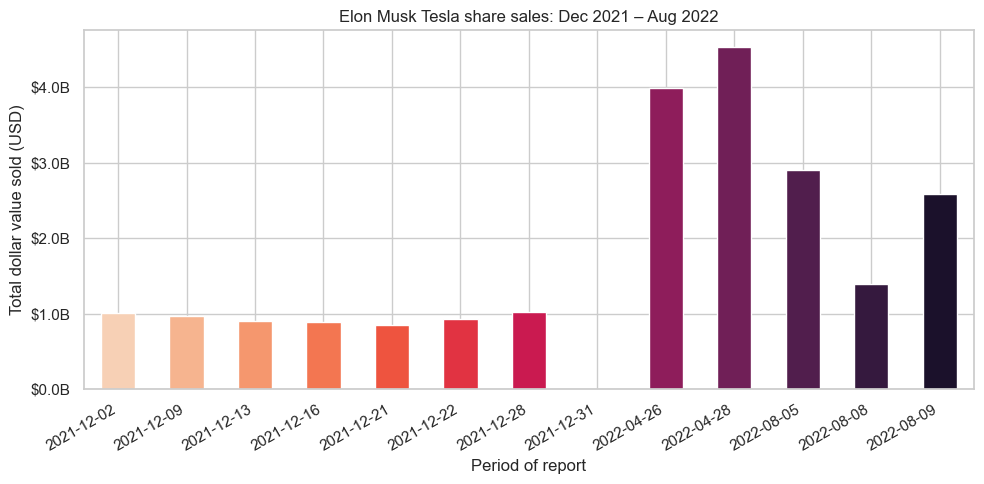

Musk transactions in window: 693
Total sold across window: $21,973,724,722


In [15]:
# Pull Musk's Dec 2021 – Aug 2022 Tesla dispositions directly.
# The base df (from cell 9) only holds the 50 most-recent TSLA filings, so
# we run a dedicated query scoped to the reporting owner and date window.
musk_query = {
    "query": 'issuer.tradingSymbol:TSLA AND reportingOwner.name:"Musk Elon" AND periodOfReport:[2021-12-01 TO 2022-08-31]',
    "from": "0",
    "size": "50",
    "sort": [{"periodOfReport": {"order": "asc"}}],
}
musk_result = insider_api.get_data(musk_query)
musk_df = pd.DataFrame(flatten_filings(musk_result["transactions"]))

musk_sales = musk_df[musk_df["acquiredDisposedCode"] == "D"].copy()
musk_daily = musk_sales.groupby("periodOfReport")["valueUSD"].sum().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
musk_daily.plot(kind="bar", ax=ax, color=sns.color_palette("rocket_r", len(musk_daily)))
ax.set_title("Elon Musk Tesla share sales: Dec 2021 – Aug 2022")
ax.set_xlabel("Period of report")
ax.set_ylabel("Total dollar value sold (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v / 1e9:.1f}B"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"Musk transactions in window: {len(musk_sales)}")
print(f"Total sold across window: ${musk_daily.sum():,.0f}")

## Visualization 2 — Heatmap of transaction codes by year

A year-by-code heatmap surfaces the dominant compensation codes (`A` — grants, `M` — option exercises, `F` — tax withholding) against the much rarer open-market activity (`P`, `S`). For most issuers, compensation codes utterly dominate Form 4 volume; the heatmap makes that imbalance visible at a glance and gives the reader a quick diagnostic for how to weight codes in downstream signal work.

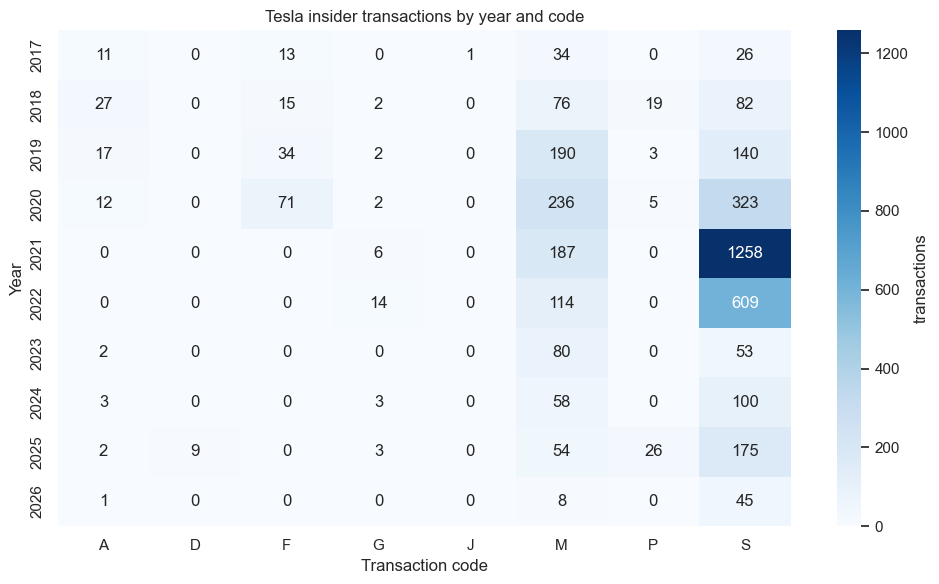

In [16]:
df_full["year"] = df_full["transactionDate"].dt.year

pivot = (
    df_full.dropna(subset=["year", "code"])
    .pivot_table(index="year", columns="code", values="shares", aggfunc="size", fill_value=0)
    .astype(int)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues", ax=ax, cbar_kws={"label": "transactions"})
ax.set_title("Tesla insider transactions by year and code")
ax.set_xlabel("Transaction code")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()

## Visualization 3 — Director vs. officer vs. 10% owner activity over time

The three Section 16 role flags aren't mutually exclusive — an insider can simultaneously be director **and** officer **and** 10% owner. To produce a one-role-per-row chart we collapse to a single `role` column using an editorial priority: `10% owner > director > officer`. You should change that priority to suit your own use case; for example, a compensation analyst might prefer `officer > director > 10% owner` so that executive pay-driven trades are separated from independent-director activity first. The chart below stacks monthly transaction counts by role for the paginated Tesla pull from Query 6.

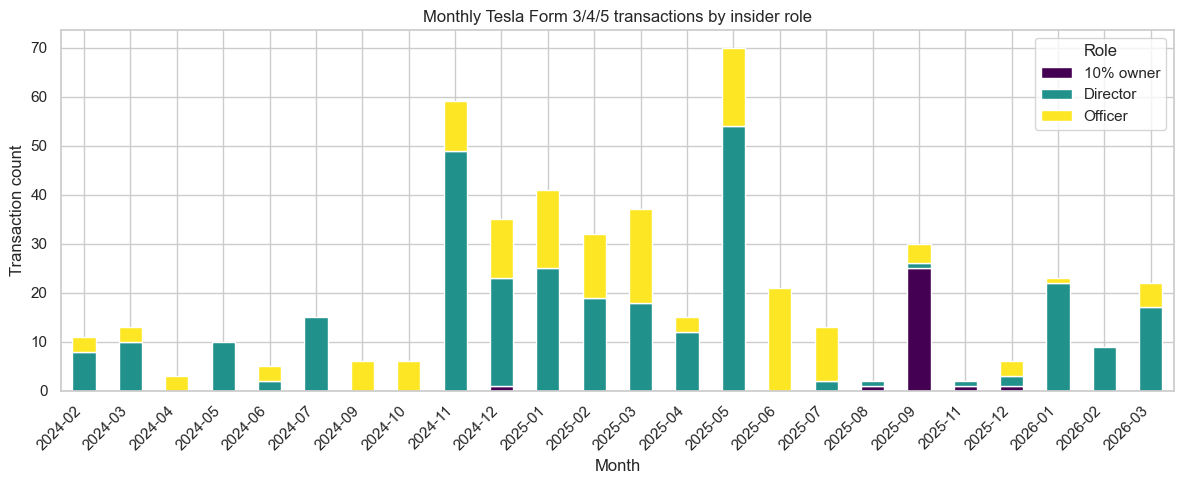

In [17]:
def classify_role(row):
    if row.get("isTenPercentOwner"):
        return "10% owner"
    if row.get("isDirector"):
        return "Director"
    if row.get("isOfficer"):
        return "Officer"
    return "Other"

df_full["role"] = df_full.apply(classify_role, axis=1)
df_full["month"] = df_full["transactionDate"].dt.to_period("M").astype(str)

role_pivot = (
    df_full.dropna(subset=["transactionDate"])
    .pivot_table(index="month", columns="role", values="shares", aggfunc="size", fill_value=0)
    .sort_index()
)

# Keep the most recent 24 months for readability.
role_pivot = role_pivot.tail(24)

fig, ax = plt.subplots(figsize=(12, 5))
role_pivot.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Monthly Tesla Form 3/4/5 transactions by insider role")
ax.set_xlabel("Month")
ax.set_ylabel("Transaction count")
ax.legend(title="Role")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Exporting results

For downstream analysis in Excel, Tableau, or a data warehouse, write the flattened DataFrame to CSV. The resulting file is tidy (one row per transaction) and stable enough to load straight into a BI tool.

In [18]:
output_path = "tesla_insider_transactions.csv"
df_full.to_csv(output_path, index=False)
print(f'Rows written: {len(df_full):,}')
print(f'File: {output_path}')

Rows written: 4,151
File: tesla_insider_transactions.csv


## Further reading

- [SEC staff Compliance and Disclosure Interpretations — Exchange Act Section 16 and Related Rules and Forms](https://www.sec.gov/rules-regulations/staff-guidance/compliance-disclosure-interpretations/exchange-act-section-16-related-rules-forms)
- [17 CFR § 240.16a-3 — Reporting transactions and holdings (Cornell LII)](https://www.law.cornell.edu/cfr/text/17/240.16a-3)
- [17 CFR § 249.104 — Form 4 prescription (Cornell LII)](https://www.law.cornell.edu/cfr/text/17/249.104)
- [SEC ownership form codes reference](https://www.sec.gov/edgar/searchedgar/ownershipformcodes.html)
- [SEC Rule 10b5-1 fact sheet (Release 33-11138)](https://www.sec.gov/files/33-11138-fact-sheet.pdf)
- [SEC press release 2022-222 — amendments to Rule 10b5-1](https://www.sec.gov/newsroom/press-releases/2022-222)
- [Davis Polk — 2024 SEC enforcement sweep on late beneficial-ownership and insider-transaction filings](https://www.davispolk.com/insights/client-update/sec-announces-enforcement-sweep-targeting-late-beneficial-ownership-and)
- [sec-api.io Insider Trading API documentation](https://sec-api.io/docs/insider-ownership-trading-api)